# CIFAR-10: Data Preparation

**Prepared by Fonyuy Gita — SEED AI Bootcamp, Deep Learning Module (CNN track)**

This notebook loads and prepares the CIFAR-10 dataset for a CNN. Unlike
the ANN projects, where we worked with tables of numbers, here we are
working with real color images, so the loading, inspection, and
preparation steps look different in a few important ways.

**A key difference from earlier projects:** instead of letting Keras
auto-download the dataset (`keras.datasets.cifar10.load_data()`), we load
it from a **local `cifar-10-python.tar.gz` file**. This matters in
classroom and lab settings with unreliable or restricted internet access,
once the `.tar.gz` file is on disk, this notebook needs no internet
connection at all to run.

**What this notebook covers:**
1. What CIFAR-10 actually is, and how the raw file is structured
2. Extract and unpickle the raw batch files
3. Reshape the raw byte data into real images
4. Inspect and visualize the data
5. Normalize and split into train / validation / test
6. Save the prepared arrays to disk, ready for the CNN training notebook


## Step 0: Get the dataset file

Download `cifar-10-python.tar.gz` (the official Python-format release of
CIFAR-10) from the CIFAR-10 homepage:

```
https://www.cs.toronto.edu/~kriz/cifar.html
```

Look for the link labeled **"CIFAR-10 python version"**. It is about
163 MB. Place `cifar-10-python.tar.gz` in the same folder as this
notebook before running the cells below.

### What is CIFAR-10?

CIFAR-10 is a classic image classification benchmark: **60,000 small
color photographs** (32x32 pixels, 3 color channels), split into
**50,000 training images and 10,000 test images**, evenly spread across
**10 classes**:

```
airplane · automobile · bird · cat · deer · dog · frog · horse · ship · truck
```

Every class has exactly 6,000 images, so unlike the medical datasets we
worked with earlier, this dataset is **perfectly balanced**, no class
imbalance to worry about here.

### How the raw file is structured

The `.tar.gz` extracts into a folder called `cifar-10-batches-py/`
containing:

```
cifar-10-batches-py/
├── data_batch_1   ┐
├── data_batch_2   │  5 training batches, 10,000 images each
├── data_batch_3   │  (50,000 images total)
├── data_batch_4   │
├── data_batch_5   ┘
├── test_batch        1 test batch, 10,000 images
└── batches.meta      class names
```

Each batch file is not a CSV or an image folder, it's a **Python pickle
file** containing a dictionary. Understanding this structure is the whole
point of this first section, since it's different from every dataset
we've worked with so far.


```mermaid
flowchart TD
    A[cifar-10-python.tar.gz] -->|extract| B[cifar-10-batches-py/ folder]
    B --> C[5 data_batch files + test_batch]
    C -->|unpickle each file| D["dict: {b'data': ..., b'labels': ...}"]
    D -->|data: shape 10000 x 3072, uint8| E[Reshape to 10000 x 3 x 32 x 32]
    E -->|transpose channels last| F[10000 x 32 x 32 x 3 real images]
    D -->|labels: list of 10000 ints, 0-9| G[NumPy array of labels]
    F --> H[Concatenate all 5 training batches]
    G --> H
    H --> I[50,000 x 32 x 32 x 3 training images + labels]
```

**Why the reshape step is needed:** each image is stored as one flat row
of 3,072 numbers, not as a 32x32x3 grid. Those 3,072 numbers are laid out
as **1,024 red values, then 1,024 green values, then 1,024 blue values**,
each block of 1,024 being the pixels of that color channel in row-major
order (left to right, top to bottom). We have to manually reshape and
reorder this back into the `(height, width, channels)` format that Keras
and matplotlib both expect for images.


## Step 1: Import libraries

In [1]:
import os
import pickle
import tarfile

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']


## Step 2: Extract the tar.gz file

This only needs to run once. If you've already extracted it, this cell
will skip re-extracting.

In [2]:
ARCHIVE_PATH = 'cifar-10-python.tar.gz'
EXTRACT_DIR = 'cifar-10-batches-py'

if not os.path.exists(EXTRACT_DIR):
    print(f"Extracting {ARCHIVE_PATH} ...")
    with tarfile.open(ARCHIVE_PATH, 'r:gz') as tar:
        tar.extractall('.')
    print("Done.")
else:
    print(f"{EXTRACT_DIR} already exists, skipping extraction.")

print(f"\nContents of {EXTRACT_DIR}:")
for name in sorted(os.listdir(EXTRACT_DIR)):
    print(f"  {name}")


Extracting cifar-10-python.tar.gz ...


C:\Users\THE EYE INFORMATIQUE\AppData\Local\Temp\ipykernel_6216\702766868.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('.')


Done.

Contents of cifar-10-batches-py:
  batches.meta
  data_batch_1
  data_batch_2
  data_batch_3
  data_batch_4
  data_batch_5
  readme.html
  test_batch


## Step 3: Unpickle the batch files

Each batch file is a Python pickle. When we load it, we get back a
dictionary with byte-string keys (`b'data'`, `b'labels'`, and so on),
that `b` prefix is a quirk of how this dataset was originally packaged
years ago, not something we introduce ourselves.

In [3]:
def unpickle(file_path):
    """Load one CIFAR-10 batch file. Returns the raw dictionary."""
    with open(file_path, 'rb') as f:
        batch_dict = pickle.load(f, encoding='bytes')
    return batch_dict


def batch_to_images_and_labels(batch_dict):
    """
    Convert one raw batch dictionary into real images and labels.

    batch_dict[b'data']   shape: (10000, 3072), uint8, flat pixel rows
    batch_dict[b'labels'] a plain list of 10000 integers (0-9)
    """
    raw_data = batch_dict[b'data']
    labels = np.array(batch_dict[b'labels'])

    # 3072 = 3 channels x 32 rows x 32 columns, stored channel-first
    images = raw_data.reshape(-1, 3, 32, 32)

    # Keras and matplotlib expect channels LAST: (height, width, channels)
    images = images.transpose(0, 2, 3, 1)

    return images, labels


# Quick test on one batch before doing all of them
sample_batch = unpickle(os.path.join(EXTRACT_DIR, 'data_batch_1'))
sample_images, sample_labels = batch_to_images_and_labels(sample_batch)

print(f"One batch, images shape: {sample_images.shape}")
print(f"One batch, labels shape: {sample_labels.shape}")
print(f"Pixel value range: {sample_images.min()} to {sample_images.max()}")


One batch, images shape: (10000, 32, 32, 3)
One batch, labels shape: (10000,)
Pixel value range: 0 to 255


C:\Users\THE EYE INFORMATIQUE\AppData\Local\Temp\ipykernel_6216\4163633071.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch_dict = pickle.load(f, encoding='bytes')


## Step 4: Load and combine all batches

Five training batches, one test batch. We load each one with the same
function and stack them together.

In [4]:
# Load and combine all 5 training batches
train_images_list = []
train_labels_list = []

for i in range(1, 6):
    batch_path = os.path.join(EXTRACT_DIR, f'data_batch_{i}')
    batch_dict = unpickle(batch_path)
    images, labels = batch_to_images_and_labels(batch_dict)
    train_images_list.append(images)
    train_labels_list.append(labels)
    print(f"data_batch_{i}: {images.shape[0]} images loaded")

X_train_full = np.concatenate(train_images_list, axis=0)
y_train_full = np.concatenate(train_labels_list, axis=0)

# Load the test batch
test_dict = unpickle(os.path.join(EXTRACT_DIR, 'test_batch'))
X_test, y_test = batch_to_images_and_labels(test_dict)

print(f"\nFull training set: {X_train_full.shape}")
print(f"Test set:           {X_test.shape}")

# Load the class names from batches.meta, cross-check against our CLASSES list
meta = unpickle(os.path.join(EXTRACT_DIR, 'batches.meta'))
class_names_from_file = [name.decode('utf-8') for name in meta[b'label_names']]
print(f"\nClass names from file: {class_names_from_file}")
assert class_names_from_file == CLASSES, "Class order mismatch, check CLASSES list"


C:\Users\THE EYE INFORMATIQUE\AppData\Local\Temp\ipykernel_6216\4163633071.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch_dict = pickle.load(f, encoding='bytes')


data_batch_1: 10000 images loaded
data_batch_2: 10000 images loaded
data_batch_3: 10000 images loaded
data_batch_4: 10000 images loaded
data_batch_5: 10000 images loaded

Full training set: (50000, 32, 32, 3)
Test set:           (10000, 32, 32, 3)

Class names from file: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Step 5: Inspect and visualize

Always look at your data before trusting it, this is just as true for
images as it was for the tables in earlier projects.

In [5]:
print(f"Training images: {X_train_full.shape[0]}")
print(f"Test images:     {X_test.shape[0]}")

unique, counts = np.unique(y_train_full, return_counts=True)
print(f"\nClass balance in training set:")
for cls_idx, count in zip(unique, counts):
    print(f"  {CLASSES[cls_idx]:<12} {count}")


Training images: 50000
Test images:     10000

Class balance in training set:
  airplane     5000
  automobile   5000
  bird         5000
  cat          5000
  deer         5000
  dog          5000
  frog         5000
  horse        5000
  ship         5000
  truck        5000


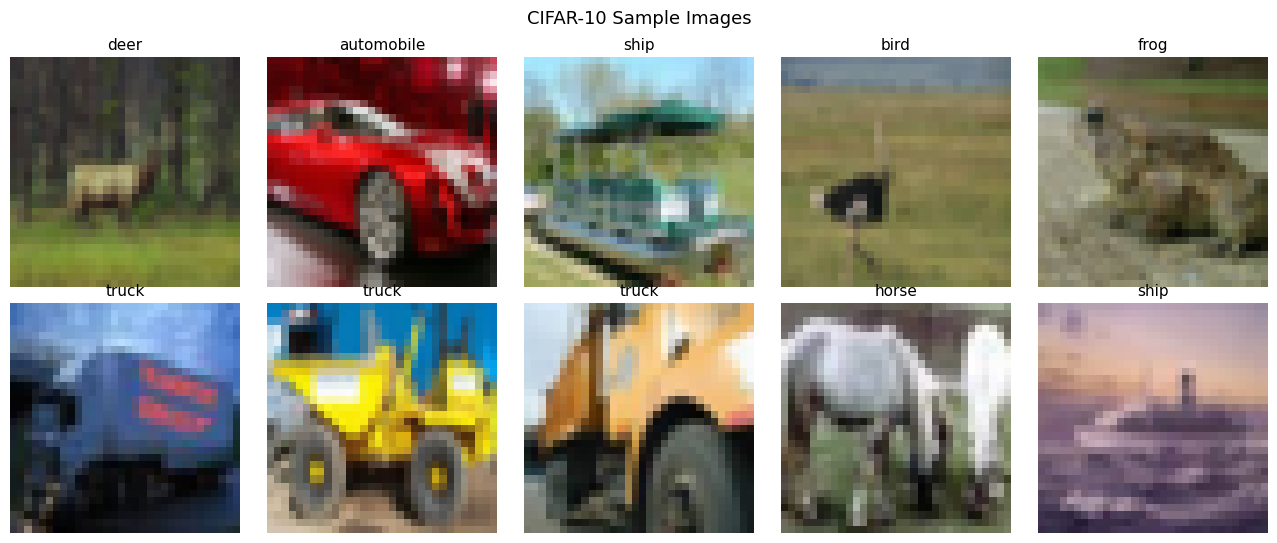

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(X_train_full), size=10, replace=False)

for ax, idx in zip(axes.flat, sample_indices):
    ax.imshow(X_train_full[idx])
    ax.set_title(CLASSES[y_train_full[idx]], fontsize=11)
    ax.axis('off')

plt.suptitle('CIFAR-10 Sample Images', fontsize=13)
plt.tight_layout()
plt.savefig('cifar_samples.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 6: Normalize pixel values

Raw pixel values range from 0 to 255 (standard 8-bit color depth). Just
like we scaled numeric features in the ANN projects, we scale image
pixels too, dividing by 255 brings every value into the range `[0, 1]`,
which neural networks train on far more smoothly than raw 0-255 integers.

In [ ]:
print(f"Before normalization: min={X_train_full.min()}, max={X_train_full.max()}, dtype={X_train_full.dtype}")

X_train_full = X_train_full.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print(f"After normalization:  min={X_train_full.min():.3f}, max={X_train_full.max():.3f}, dtype={X_train_full.dtype}")


## Step 7: Split off a validation set

CIFAR-10 ships with a train/test split already, but not a validation
set. We carve one out of the training data ourselves, the same idea as
`train_test_split` in earlier projects, just done manually here since we
want a simple slice rather than a random stratified split (the training
set is already perfectly balanced and shuffled batch-to-batch).

In [ ]:
VAL_SIZE = 5000

X_val = X_train_full[-VAL_SIZE:]
y_val = y_train_full[-VAL_SIZE:]
X_train = X_train_full[:-VAL_SIZE]
y_train = y_train_full[:-VAL_SIZE]

print(f"Train: {X_train.shape[0]}")
print(f"Val:   {X_val.shape[0]}")
print(f"Test:  {X_test.shape[0]}")


## Step 8: Save the prepared arrays

A quick note on file format: earlier projects (tabular data) saved as
CSV and JSON, since a spreadsheet-style table is a natural fit for rows
of numbers. Images don't fit that shape well, a single CIFAR-10 image
already has 3,072 numbers, so a CSV of 45,000 images would be an
enormous, slow-to-read text file for no benefit.

Instead, we save images using **NumPy's native binary format (`.npy`)**,
which is the standard choice for array data like this: compact, fast to
load, and preserves the exact shape and data type of the array.

In [ ]:
np.save('cifar_X_train.npy', X_train)
np.save('cifar_y_train.npy', y_train)
np.save('cifar_X_val.npy', X_val)
np.save('cifar_y_val.npy', y_val)
np.save('cifar_X_test.npy', X_test)
np.save('cifar_y_test.npy', y_test)

print("Saved:")
print("  cifar_X_train.npy, cifar_y_train.npy")
print("  cifar_X_val.npy,   cifar_y_val.npy")
print("  cifar_X_test.npy,  cifar_y_test.npy")

import json
with open('cifar_classes.json', 'w') as f:
    json.dump(CLASSES, f, indent=2)
print("  cifar_classes.json")


### Done

We now have clean, normalized CIFAR-10 image arrays saved to disk, ready
for training. Open **`02_cifar10_cnn_training.ipynb`** next to build and
train the CNN.